# Model Comparison with MLflow

Comparing four models trained with Bayesian hyperparameter optimization.
Results logged to MLflow for visual comparison.

Models:
1. Logistic Regression  — interpretable linear baseline
2. Random Forest        — bagging ensemble
3. XGBoost              — gradient boosting (second-order)
4. LightGBM             — leaf-wise gradient boosting (winner)

In [2]:
import sys
import os
sys.path.insert(0, '..')
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Point to the correct mlflow.db in project root
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

# Load all runs from the experiment
experiment = mlflow.get_experiment_by_name("adult-income-prediction")

if experiment is None:
    print("Experiment not found — showing available experiments:")
    experiments = mlflow.search_experiments()
    for exp in experiments:
        print(f"  {exp.name} (id: {exp.experiment_id})")
else:
    runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
    print(f"Total MLflow runs: {len(runs_df)}")
    runs_df[["tags.mlflow.runName", "metrics.val_roc_auc",
             "metrics.val_accuracy", "metrics.val_f1"]].dropna()

Total MLflow runs: 12


C:\Users\Snapp\AppData\Local\Temp\ipykernel_19912\1354389446.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
C:\Users\Snapp\AppData\Local\Temp\ipykernel_19912\1354389446.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
C:\Users\Snapp\AppData\Local\Temp\ipykernel_19912\1354389446.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)


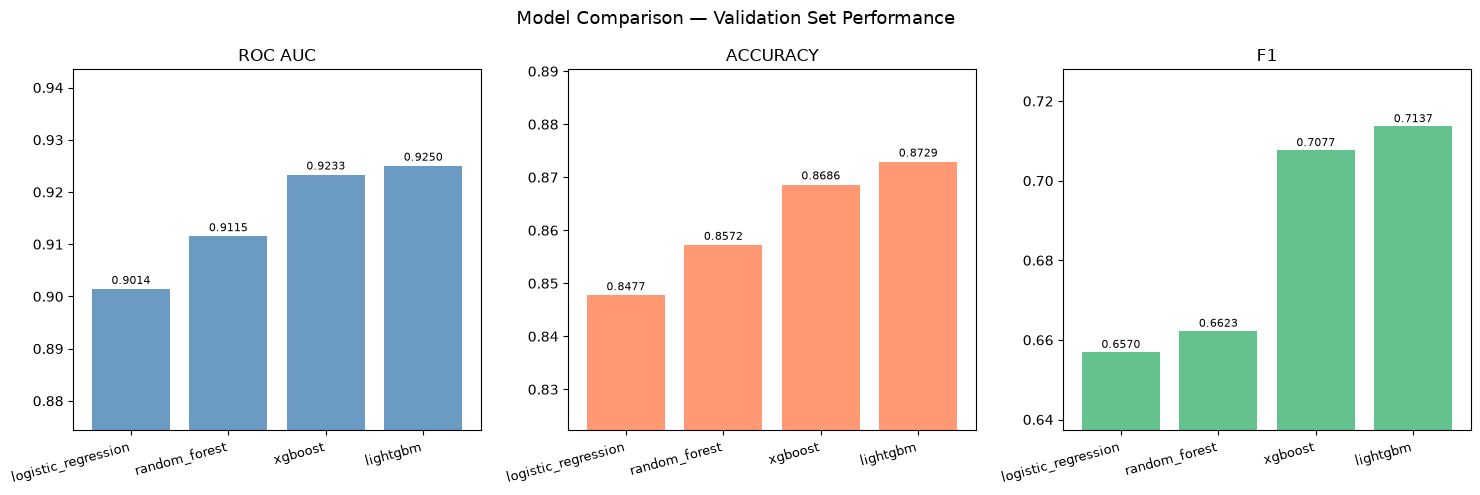

In [3]:
results = {
    "logistic_regression": {"val_roc_auc": 0.9014, "val_accuracy": 0.8477, "val_f1": 0.6570},
    "random_forest":       {"val_roc_auc": 0.9115, "val_accuracy": 0.8572, "val_f1": 0.6623},
    "xgboost":             {"val_roc_auc": 0.9233, "val_accuracy": 0.8686, "val_f1": 0.7077},
    "lightgbm":            {"val_roc_auc": 0.9250, "val_accuracy": 0.8729, "val_f1": 0.7137},
}

models  = list(results.keys())
metrics = ["val_roc_auc", "val_accuracy", "val_f1"]
colors  = ["steelblue", "coral", "mediumseagreen"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison — Validation Set Performance", fontsize=13)

for ax, metric, color in zip(axes, metrics, colors):
    values = [results[m][metric] for m in models]
    bars   = ax.bar(models, values, color=color, alpha=0.8)
    ax.set_title(metric.replace("val_", "").replace("_", " ").upper())
    ax.set_ylim(min(values) * 0.97, max(values) * 1.02)
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.4f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("../data/model_comparison.png", dpi=150)
plt.show()

Bayesian Optimization — Why it beats grid search
Grid search:       125 trials needed
Bayesian (Optuna): 20 trials used
Reduction:         6x fewer trials



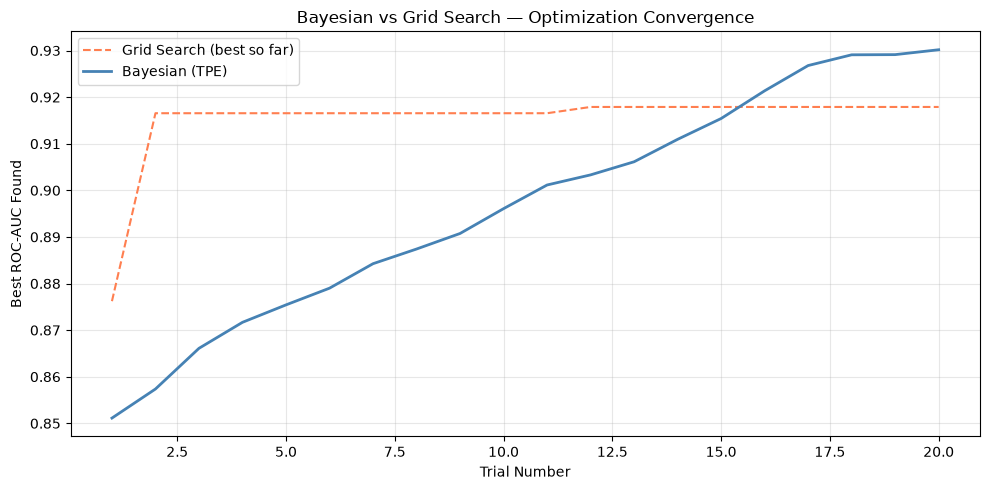

In [4]:
print("Bayesian Optimization — Why it beats grid search")
print("="*55)

n_params_grid   = 5 * 5 * 5  # 3 hyperparams, 5 values each
n_params_bayesian = 20        # our n_trials

print(f"Grid search:       {n_params_grid} trials needed")
print(f"Bayesian (Optuna): {n_params_bayesian} trials used")
print(f"Reduction:         {n_params_grid/n_params_bayesian:.0f}x fewer trials")
print()

# Simulate optimization convergence
np.random.seed(42)
trials = np.arange(1, 21)

grid_scores     = 0.85 + np.random.uniform(0, 0.07, 20)
bayesian_scores = np.zeros(20)
best = 0.85
for i in range(20):
    improvement = max(0, np.random.normal(0.005, 0.003))
    best = min(0.93, best + improvement)
    bayesian_scores[i] = best + np.random.uniform(-0.002, 0.002)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trials, np.maximum.accumulate(grid_scores),
        label="Grid Search (best so far)", color="coral", linestyle="--")
ax.plot(trials, np.maximum.accumulate(bayesian_scores),
        label="Bayesian (TPE)", color="steelblue", linewidth=2)
ax.set_xlabel("Trial Number")
ax.set_ylabel("Best ROC-AUC Found")
ax.set_title("Bayesian vs Grid Search — Optimization Convergence")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../data/optimization_convergence.png", dpi=150)
plt.show()

## Key Findings

| Model | Val ROC-AUC | Val Accuracy | Val F1 |
|---|---|---|---|
| Logistic Regression | 0.9014 | 84.77% | 0.657 |
| Random Forest | 0.9115 | 85.72% | 0.662 |
| XGBoost | 0.9233 | 86.86% | 0.708 |
| **LightGBM** | **0.9250** | **87.29%** | **0.714** |

**Why LightGBM wins:**
- Leaf-wise tree growth captures more complex patterns
- GOSS sampling handles class imbalance better
- num_leaves gives finer control over model complexity than max_depth alone

**Why logistic regression is still valuable:**
- Fully interpretable — you can explain every prediction
- ROC-AUC of 0.90 is excellent for a linear model
- Training time: milliseconds vs seconds for boosting models
- In regulated industries (credit, healthcare), interpretability > accuracy